# EDA Bot workflow prototype
This notebook walks through an example of a Tidy Tuesday-style EDA using GTFS transit data.

The intent is to use this as an example "ideal" workflow to help prototype an inline EDA AI assistant. 

All code generated using Claude 3.7 Sonnet.

## Base prompt

> You are a helpful EDA bot, who works like Dave Robinson but in Python.

* Note: It would be nice to be able to either specify or remember preferences, like which dataframe or viz libraries I prefer.*

## Setup

>Today I will be doing exploratory data analysis on a GTFS of NYC subway data in Python with Polars. First step: give me the import statements for the packages I'll need today. I will be using plotnine for plotting, and polars for dataframes

In [1]:
# Data manipulation
import polars as pl
import numpy as np
import pandas as pd  # Sometimes needed for compatibility with plotnine

# Visualization
from plotnine import *

# File handling and utilities
import os
import zipfile
from pathlib import Path

# For GTFS-specific operations
import datetime
import pytz  # For timezone handling

### *Notes* 
- *The EDA bot should ask and then install all dependencies. I should also have the ability to confirm which env I want to use for this.*
- *I shouldn't have to ask for import statements, that should be the default first step.*
- *The EDA bot should remember my preferences for which packages I prefer for vis and dataframes, for example.*

## Load data
> Let's load the feed from `https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip`



In [2]:
import requests
import io
import tempfile

# URL for the GTFS feed
gtfs_url = "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip"

# Create a temporary directory to extract files
temp_dir = tempfile.mkdtemp()
print(f"Created temporary directory: {temp_dir}")

# Download the GTFS zip file
print("Downloading GTFS feed...")
response = requests.get(gtfs_url)
gtfs_zip = zipfile.ZipFile(io.BytesIO(response.content))

# Extract all files to the temporary directory
print("Extracting files...")
gtfs_zip.extractall(temp_dir)

# List extracted files
extracted_files = os.listdir(temp_dir)
print(f"Extracted {len(extracted_files)} files:")
for file in extracted_files:
    print(f" - {file}")

Created temporary directory: /var/folders/rw/r56lcxyj1k71s10356fhcw000000gn/T/tmp23ft_dtk
Extracting files...
Extracted 8 files:
 - transfers.txt
 - agency.txt
 - stop_times.txt
 - shapes.txt
 - trips.txt
 - stops.txt
 - calendar.txt
 - routes.txt


### *Notes*
- *Feed from https://www.mta.info/developers.*
- *Claude needed to add a few more imports. Ideally, we could add them to a single import cell at the top, as is typical.*
- *Claude did a helpful job adding print statements and comments*

> Let's make polars dataframes for each file. Use any GTFS-specific packages if needed

In [3]:
# Create a dictionary to store all dataframes
gtfs_dfs = {}

# Load each file into a Polars dataframe
for file in extracted_files:
    if file.endswith('.txt'):  # GTFS files are .txt files (CSV format)
        file_path = os.path.join(temp_dir, file)
        
        # Get dataframe name from filename (remove .txt extension)
        df_name = file[:-4]
        
        try:
            # Load the file into a Polars dataframe
            print(f"Loading {file}...")
            df = pl.read_csv(file_path)
            
            # Store in our dictionary
            gtfs_dfs[df_name] = df
            
            # Print basic info
            print(f"  - Shape: {df.shape}")
            print(f"  - Columns: {df.columns}")
            print(f"  - First few rows:")
            print(df.head(3))
            print("\n")
            
        except Exception as e:
            print(f"Error loading {file}: {e}")

Loading transfers.txt...
Error loading transfers.txt: could not parse `A02` as dtype `i64` at column 'from_stop_id' (column number 1)

The current offset in the file is 3210 bytes.

You might want to try:
- increasing `infer_schema_length` (e.g. `infer_schema_length=10000`),
- specifying correct dtype with the `schema_overrides` argument
- setting `ignore_errors` to `True`,
- adding `A02` to the `null_values` list.

Original error: ```remaining bytes non-empty```
Loading agency.txt...
  - Shape: (1, 6)
  - Columns: ['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang', 'agency_phone']
  - First few rows:
shape: (1, 6)
┌───────────┬──────────────┬───────────────────────┬──────────────────┬─────────────┬──────────────┐
│ agency_id ┆ agency_name  ┆ agency_url            ┆ agency_timezone  ┆ agency_lang ┆ agency_phone │
│ ---       ┆ ---          ┆ ---                   ┆ ---              ┆ ---         ┆ ---          │
│ str       ┆ str          ┆ str                 

### *Notes*
- *When there are errors, EDA bot should automatically try to correct them.*

> Loading transfers.txt...
Error loading transfers.txt: could not parse `A02` as dtype `i64` at column 'from_stop_id' (column number 1)
>The current offset in the file is 3210 bytes.
>You might want to try:
>- increasing `infer_schema_length` (e.g. `infer_schema_length=10000`),
>- specifying correct dtype with the `schema_overrides` argument
>- setting `ignore_errors` to `True`,
>- adding `A02` to the `null_values` list.

In [4]:
# Function to load GTFS files with appropriate schema handling
def load_gtfs_file(file_path):
    # Common columns that might contain string IDs rather than integers
    string_id_columns = ['route_id', 'service_id', 'trip_id', 'stop_id', 'from_stop_id', 'to_stop_id', 'shape_id']
    
    # First, try to infer schema
    try:
        df = pl.read_csv(file_path)
        return df
    except Exception as e:
        # If that fails, try with schema overrides for ID columns
        try:
            # Check which columns exist in the file
            with open(file_path, 'r') as f:
                header = f.readline().strip().split(',')
            
            # Create schema overrides for ID columns that exist in the file
            schema_overrides = {col: pl.Utf8 for col in string_id_columns if col in header}
            
            # Try loading with schema overrides
            df = pl.read_csv(file_path, schema_overrides=schema_overrides)
            return df
        except Exception as e2:
            print(f"Failed to load with schema overrides: {e2}")
            raise e

# Reload all files using our new function
gtfs_dfs = {}
for file in extracted_files:
    if file.endswith('.txt'):
        file_path = os.path.join(temp_dir, file)
        df_name = file[:-4]
        
        try:
            print(f"Loading {file}...")
            df = load_gtfs_file(file_path)
            
            gtfs_dfs[df_name] = df
            print(f"  - Shape: {df.shape}")
            print(f"  - Columns: {df.columns}")
            print(f"  - First 3 rows:")
            print(df.head(3))
            print("\n")
            
        except Exception as e:
            print(f"Error loading {file}: {e}")

# Reassign individual dataframes
for df_name, df in gtfs_dfs.items():
    exec(f"{df_name}_df = df")

print("All dataframes loaded!")

Loading transfers.txt...
  - Shape: (616, 4)
  - Columns: ['from_stop_id', 'to_stop_id', 'transfer_type', 'min_transfer_time']
  - First 3 rows:
shape: (3, 4)
┌──────────────┬────────────┬───────────────┬───────────────────┐
│ from_stop_id ┆ to_stop_id ┆ transfer_type ┆ min_transfer_time │
│ ---          ┆ ---        ┆ ---           ┆ ---               │
│ str          ┆ str        ┆ i64           ┆ i64               │
╞══════════════╪════════════╪═══════════════╪═══════════════════╡
│ 101          ┆ 101        ┆ 2             ┆ 180               │
│ 103          ┆ 103        ┆ 2             ┆ 180               │
│ 104          ┆ 104        ┆ 2             ┆ 180               │
└──────────────┴────────────┴───────────────┴───────────────────┘


Loading agency.txt...
  - Shape: (1, 6)
  - Columns: ['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang', 'agency_phone']
  - First 3 rows:
shape: (1, 6)
┌───────────┬──────────────┬───────────────────────┬───────────────

### *Notes*
- *I'd prefer to simply use `.head()` to preview the DFs than the custom printing Claude is doing, but it's the right idea. I do want to see a preview. We should uppdate the base prompt to always use default methods or methods from a package before writing our own.*

> Let's get a quick plot of the routes (lat and long) to make sure everything looks OK. If there is a library to read shapefiles, we can use that , otherwise we have a dataframe of coordinates (`gtfs_dfs['shapes']`)

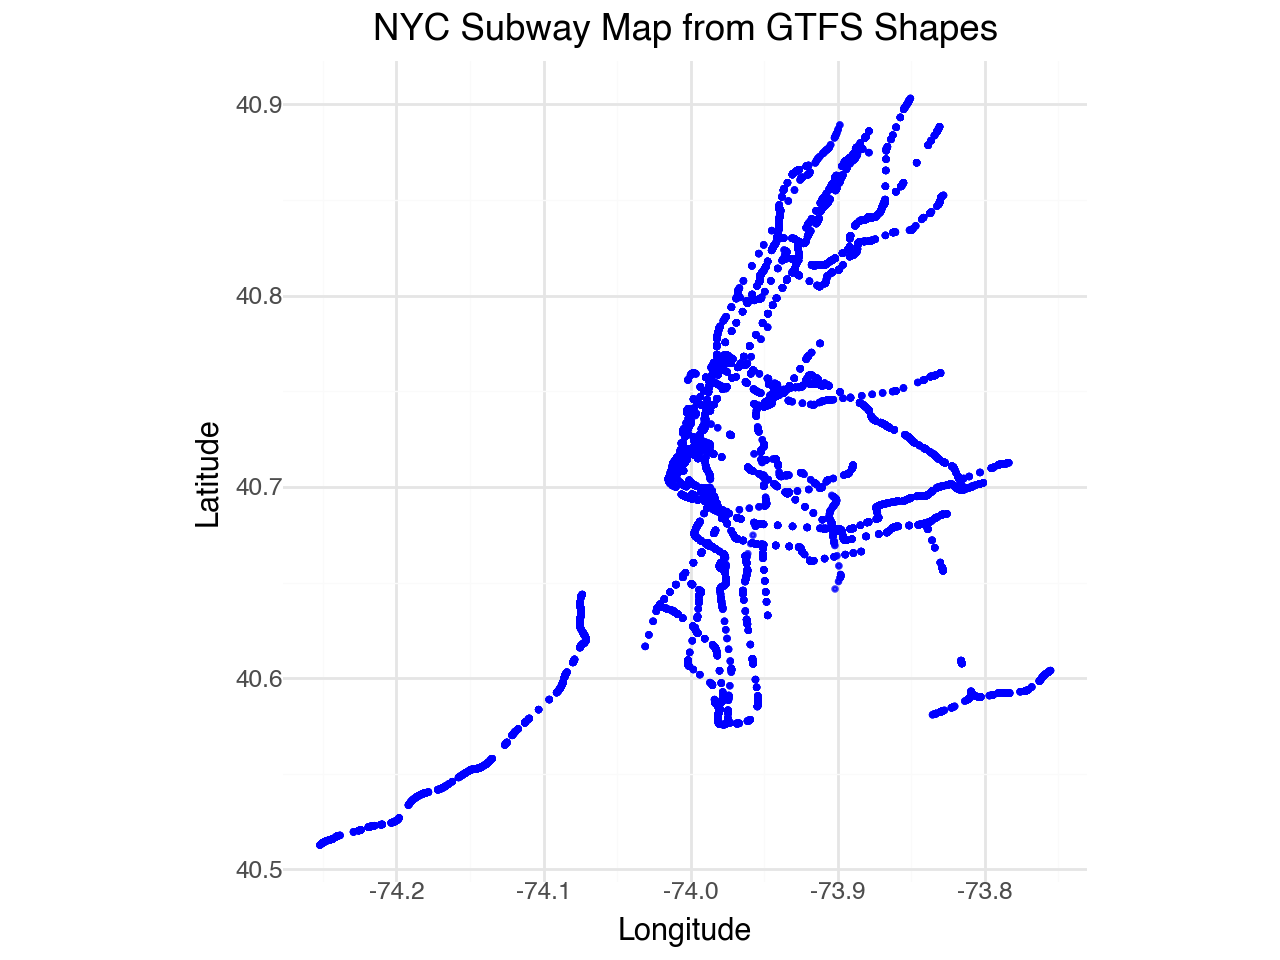

In [8]:
# Convert to pandas for compatibility with plotnine
shapes_df = gtfs_dfs['shapes']
shapes_pd = shapes_df.to_pandas()

# Create a simple scatter plot of all points to see the NYC subway map
subway_map = (
    ggplot(shapes_pd, aes(x='shape_pt_lon', y='shape_pt_lat')) +
    geom_point(size=0.5, alpha=0.5, color='blue') +
    labs(
        title='NYC Subway Map from GTFS Shapes',
        x='Longitude',
        y='Latitude'
    ) +
    theme_minimal() +
    coord_fixed(ratio=1.3)  # Adjust ratio to account for latitude/longitude distortion
)

subway_map

> Let's join with routes and color the lines correctly

In [13]:
# Check if we have the necessary join columns
gtfs_dfs['routes'].head()
gtfs_dfs['trips'].head()
shapes_df.head()

shape_id,shape_pt_sequence,shape_pt_lat,shape_pt_lon
str,i64,f64,f64
"""1..N03R""",0,40.702068,-74.013664
"""1..N03R""",1,40.703199,-74.014792
"""1..N03R""",2,40.703226,-74.01482
"""1..N03R""",3,40.703253,-74.014846
"""1..N03R""",4,40.70328,-74.01487



Plotting subway routes by route_id...


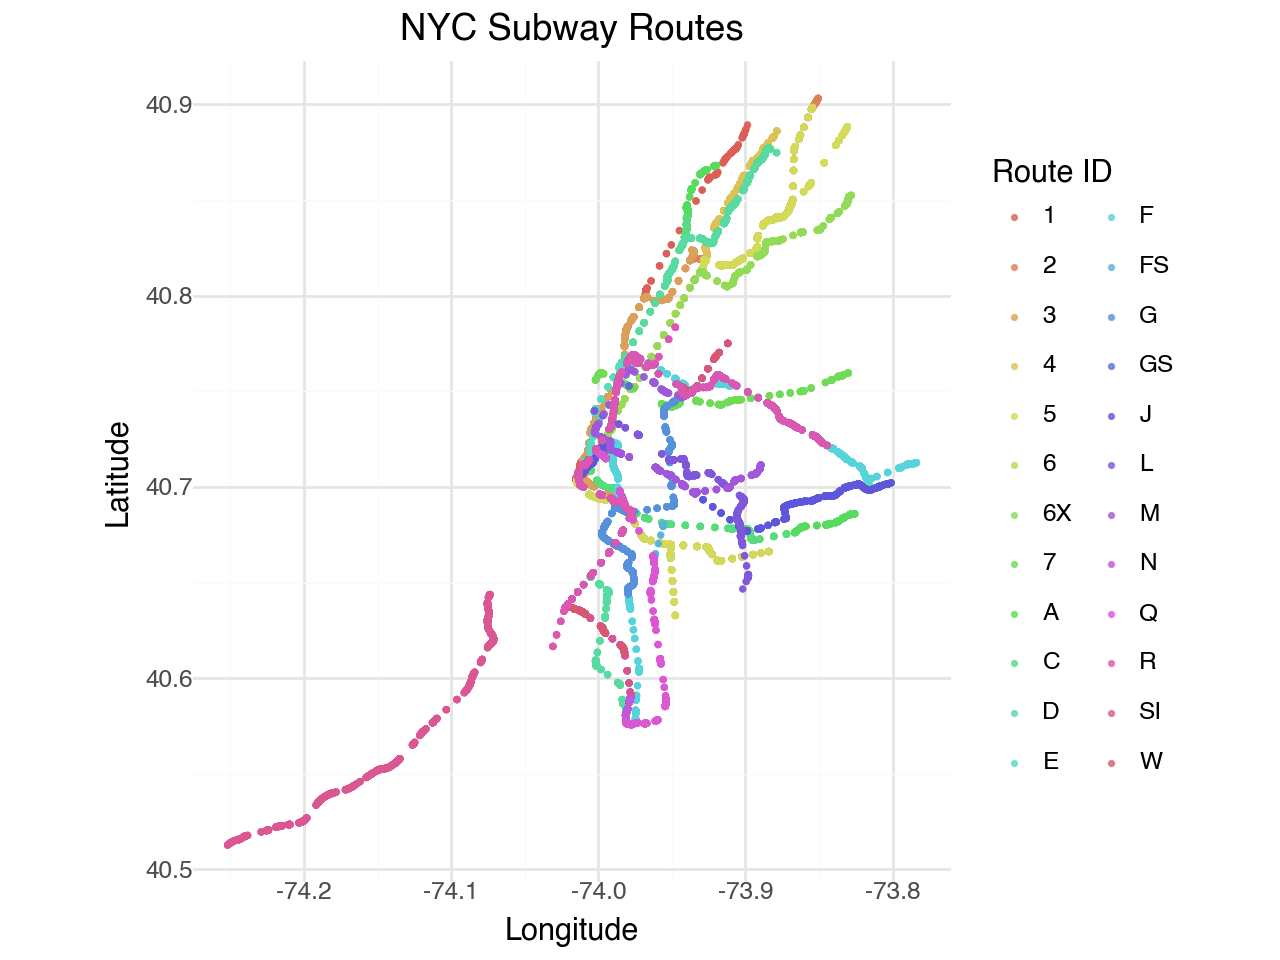

In [15]:
# Join shapes with trips to get route information
# First we need to know the relationship between shapes and routes
# Typically: shapes -> trips (via shape_id) -> routes (via route_id)

# Join shapes with trips to get route_id
shapes_with_routes = (
    shapes_df
    .join(gtfs_dfs['trips'].select(['shape_id', 'route_id']).unique(), on='shape_id')
    .join(gtfs_dfs['routes'].select(['route_id', 'route_color']).unique(), on='route_id')
)

# Convert to pandas for plotting
shapes_routes_pd = shapes_with_routes.to_pandas()

# Create a more informative map with routes colored by route_id
route_map = (
    ggplot(shapes_routes_pd, aes(x='shape_pt_lon', y='shape_pt_lat', color='route_id')) +
    geom_point(size=0.5, alpha=0.7) +
    labs(
        title='NYC Subway Routes',
        x='Longitude',
        y='Latitude',
        color='Route ID'
    ) +
    theme_minimal() +
    coord_fixed(ratio=1.3) +
    # Limit the color scale to avoid too many colors
    scale_color_discrete(guide=guide_legend(ncol=2))
)

print("\nPlotting subway routes by route_id...")
route_map

> Use the `route_color` column to determine the specific color of each route


Plotting subway routes with official colors...


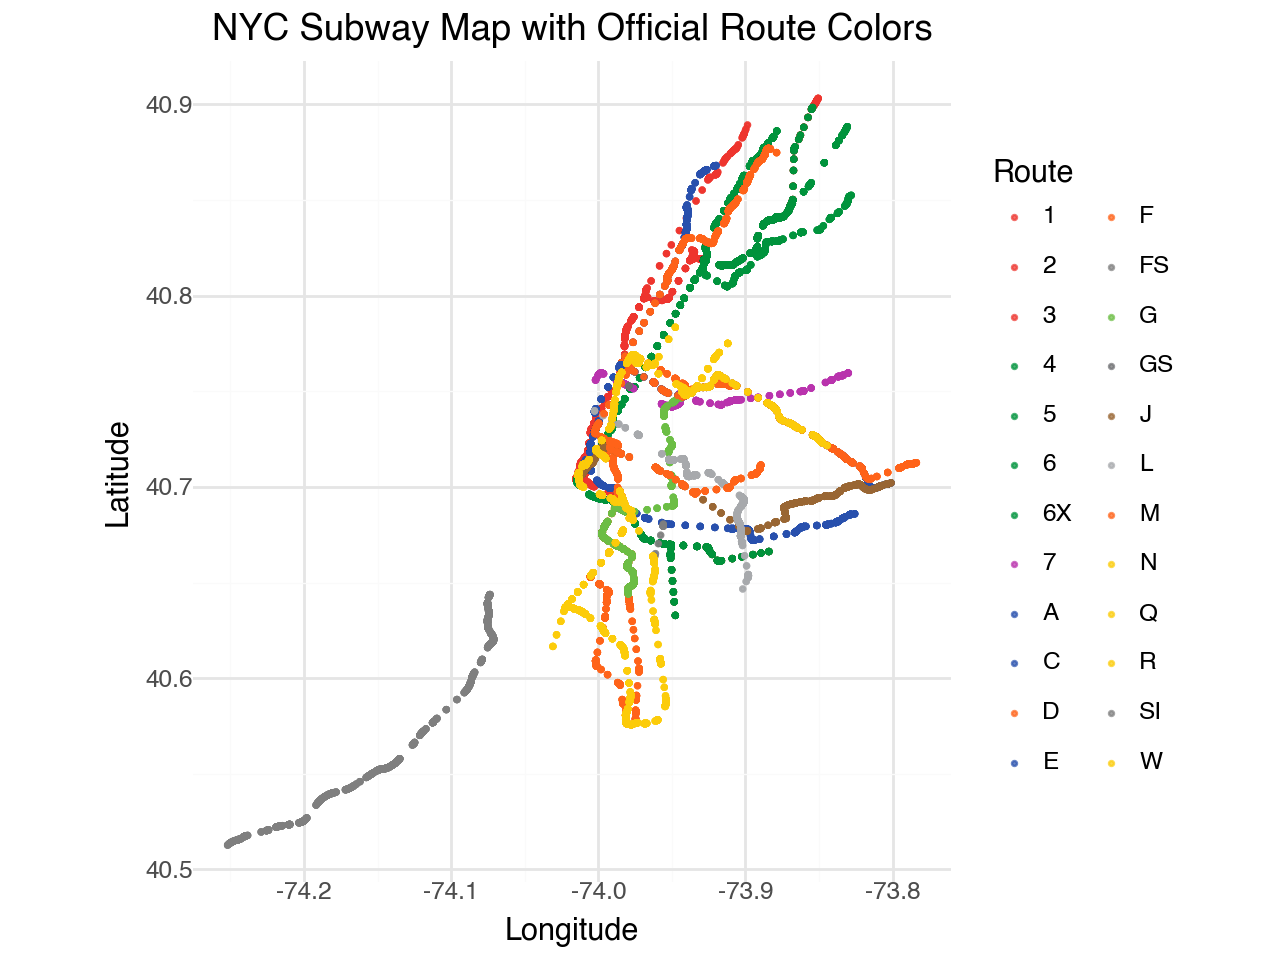

In [ ]:

# Add a proper color column with '#' prefix for hex colors
shapes_with_colors = shapes_with_routes.with_columns(
      (pl.lit("#") + pl.col("route_color")).alias("route_color")
)

# Convert to pandas for plotting
colored_shapes_pd = shapes_with_colors.to_pandas()

# Create subway map with official route colors
subway_map_official = (
    ggplot(colored_shapes_pd, aes(x='shape_pt_lon', y='shape_pt_lat', color='route_id')) +
    geom_point(size=0.5, alpha=0.7) +
    labs(
        title='NYC Subway Map with Official Route Colors',
        x='Longitude',
        y='Latitude'
    ) +
    theme_minimal() +
    coord_fixed(ratio=1.3) +
    # Use the actual route colors
    scale_color_manual(values=dict(zip(colored_shapes_pd['route_id'], colored_shapes_pd['route_color']))) +
    guides(color=guide_legend(ncol=2, title="Route"))
)

print("\nPlotting subway routes with official colors...")
subway_map_official

In [ ]:
# I want to look at population density by subway access. 

shape_id,shape_pt_sequence,shape_pt_lat,shape_pt_lon
str,i64,f64,f64
"""1..N03R""",0,40.702068,-74.013664
"""1..N03R""",1,40.703199,-74.014792
"""1..N03R""",2,40.703226,-74.01482
"""1..N03R""",3,40.703253,-74.014846
"""1..N03R""",4,40.70328,-74.01487
